# MLE_codes.ipynb：图形与数据生成

**文件用途**：本笔记是「最大似然估计」章节的**素材工厂**，负责生成讲义 `MLE_lec.qmd` 中引用的所有图形，以及供 `MLE_case.ipynb` 使用的模拟数据集。

**输出**：
- 图形保存至 `./figs/`，共 8 张，命名规则：`method_MLE_fig0N_xxx.png`
- 数据保存至 `./data/`，共 3 个，命名规则：`method_MLE_data0N_xxx.csv`

**执行顺序**：请从头到尾顺序执行所有 Cell，以确保随机数种子和数据一致性。

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from scipy import stats
from scipy.optimize import minimize
from scipy.special import expit  # Logistic 函数
import os

# 创建输出文件夹
os.makedirs('./figs', exist_ok=True)
os.makedirs('./data', exist_ok=True)

# ── 全局绘图设置 ──────────────────────────────────────────────
# 中文字体：Windows 用 SimHei，Linux 用 Noto Sans CJK SC 或 WenQuanYi Micro Hei
import platform
if platform.system() == 'Windows':
    FONT_FAMILY = 'SimHei'
else:
    # Linux/macOS 回退方案：优先尝试常见中文字体
    import matplotlib.font_manager as fm
    available = [f.name for f in fm.fontManager.ttflist]
    for candidate in ['Noto Sans CJK SC', 'WenQuanYi Micro Hei', 'Source Han Sans CN', 'SimHei']:
        if candidate in available:
            FONT_FAMILY = candidate
            break
    else:
        FONT_FAMILY = 'DejaVu Sans'  # 最终回退，中文将显示为方块

plt.rcParams.update({
    'font.family':        FONT_FAMILY,
    'axes.unicode_minus': False,
    'figure.dpi':         150,
    'savefig.dpi':        300,
    'figure.figsize':     (6, 4),
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'lines.linewidth':    1.5,
    'font.size':          10,
    'axes.titlesize':     12,
    'axes.labelsize':     10,
    'legend.fontsize':    9,
})

# ── 颜色方案 ─────────────────────────────────────────────────
COLOR_PRIMARY   = '#2C6BAC'   # 主色：蓝色
COLOR_SECONDARY = '#E8A020'   # 辅色：橙黄色
COLOR_NEUTRAL   = "#152DCE"   # 中性：灰色
COLOR_FILL      = '#D6E8F7'   # 填充：淡蓝
COLOR_GREEN     = '#2CA02C'   # 绿色（用于参数化图的第三行）
COLOR_ORANGE    = "#A54F04"   # 橙色（用于参数化图的第二行）

print('环境设置完成')
print(f'使用字体：{FONT_FAMILY}')

环境设置完成
使用字体：SimHei


---
## Section 1：总流程图

**图形说明**：展示 MLE 的完整分析链条，是讲义的「导航图」，在导言和小结中均需引用。

**对应讲义**：导言、第 6 节、第 9 节小结

**保存路径**：`./figs/method_MLE_fig01_flowchart.png`

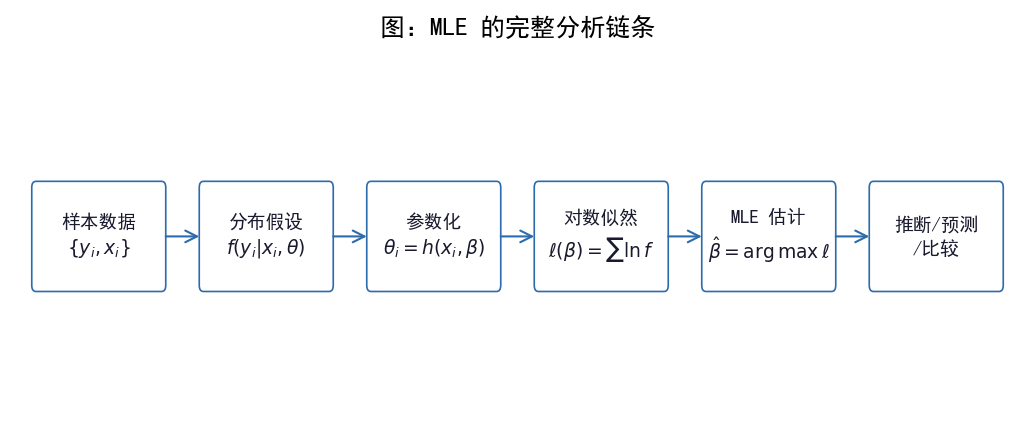

fig01 已保存


In [131]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.set_xlim(0, 12)
ax.set_ylim(0, 3)
ax.axis('off')

nodes = [
    (1.0,  '样本数据\n$\{y_i, x_i\}$'),
    (3.0,  '分布假设\n$f(y_i|x_i,\\theta)$'),
    (5.0,  '参数化\n$\\theta_i = h(x_i,\\beta)$'),
    (7.0,  '对数似然\n$\\ell(\\beta)=\\sum\\ln f$'),
    (9.0,  'MLE 估计\n$\\hat{\\beta}=\\arg\\max\\,\\ell$'),
    (11.0, '推断/预测\n/比较'),
]

box_w, box_h = 1.5, 0.8
for cx, label in nodes:
    fancy = FancyBboxPatch(
        (cx - box_w/2, 1.5 - box_h/2), box_w, box_h,
        boxstyle='round,pad=0.05',
        facecolor="#ffffffff", edgecolor=COLOR_PRIMARY, linewidth=0.8
    )
    ax.add_patch(fancy)
    ax.text(cx, 1.5, label, ha='center', va='center',
            fontsize=9, color='#1a1a2e', linespacing=1.4)

# 箭头
for i in range(len(nodes) - 1):
    x_start = nodes[i][0]   + box_w/2
    x_end   = nodes[i+1][0] - box_w/2
    ax.annotate('', xy=(x_end, 1.5), xytext=(x_start, 1.5),
                arrowprops=dict(arrowstyle='->', color=COLOR_PRIMARY,
                                lw=1.0, mutation_scale=14))

ax.set_title('图：MLE 的完整分析链条', fontsize=12, pad=8)
plt.tight_layout()
plt.savefig('./figs/method_MLE_fig01_flowchart.png', dpi=300, bbox_inches='tight')
plt.show()
print('fig01 已保存')

---
## Section 2：概率 vs. 似然对比图

**图形说明**：用出行方式例子直观说明概率与似然的根本区别。左图为概率视角（参数固定，数据在变）；右图为似然视角（数据固定，参数在变）。

**对应讲义**：第 2 节

**保存路径**：`./figs/method_MLE_fig02_prob_vs_likelihood.png`

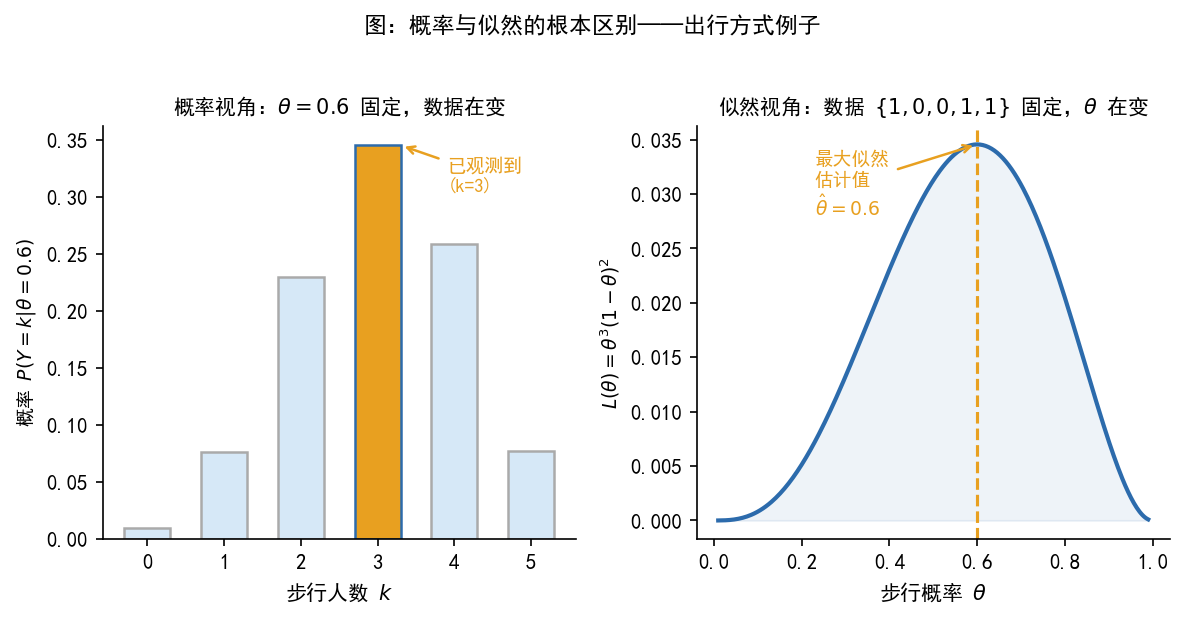

fig02 已保存


In [55]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

# ── 左图：概率视角 ────────────────────────────────────────────
k_vals = np.arange(0, 6)
probs  = stats.binom.pmf(k_vals, n=5, p=0.6)
colors_bar = [COLOR_SECONDARY if k == 3 else COLOR_FILL for k in k_vals]
edge_colors = [COLOR_PRIMARY if k == 3 else '#aaaaaa' for k in k_vals]

bars = ax1.bar(k_vals, probs, color=colors_bar, edgecolor=edge_colors,
               linewidth=1.2, width=0.6)
ax1.annotate('已观测到\n(k=3)',
             xy=(3.3, probs[3]), xytext=(3.9, probs[3] - 0.04),
             fontsize=9, color=COLOR_SECONDARY,
             arrowprops=dict(arrowstyle='->', color=COLOR_SECONDARY, lw=1.2))
ax1.set_xlabel('步行人数 $k$', fontsize=10)
ax1.set_ylabel('概率 $P(Y=k|\\theta=0.6)$', fontsize=9)
ax1.set_title('概率视角：$\\theta=0.6$ 固定，数据在变', fontsize=10)
ax1.set_xticks(k_vals)

# ── 右图：似然视角 ────────────────────────────────────────────
theta = np.linspace(0.01, 0.99, 300)
L     = theta**3 * (1 - theta)**2

ax2.plot(theta, L, color=COLOR_PRIMARY, lw=2)
ax2.fill_between(theta, L, alpha=0.08, color=COLOR_PRIMARY)
ax2.axvline(0.6, color=COLOR_SECONDARY, lw=1.5, ls='--')
ax2.annotate('最大似然\n估计值\n$\\hat{\\theta}=0.6$',
             xy=(0.6, L[np.argmin(np.abs(theta - 0.6))]),
             xytext=(0.23, 0.028),
             fontsize=9, color=COLOR_SECONDARY,
             arrowprops=dict(arrowstyle='->', color=COLOR_SECONDARY, lw=1.2))
ax2.set_xlabel('步行概率 $\\theta$', fontsize=10)
ax2.set_ylabel('$L(\\theta) = \\theta^3(1-\\theta)^2$', fontsize=9)
ax2.set_title('似然视角：数据 $\{1,0,0,1,1\}$ 固定，$\\theta$ 在变', fontsize=10)

fig.suptitle('图：概率与似然的根本区别——出行方式例子', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('./figs/method_MLE_fig02_prob_vs_likelihood.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('fig02 已保存')

---
## Section 3：Bernoulli 例子图形

### fig03：$L(\theta)$ 与 $\ln L(\theta)$ 形状对比

**图形说明**：展示 Bernoulli 例子（5 人中 3 人步行）的似然函数与对数似然函数，说明两者峰值位置相同，但对数形式在数值计算上更稳定。

**对应讲义**：第 2 节、第 3 节

**保存路径**：`./figs/method_MLE_fig03_bernoulli_likelihood.png`

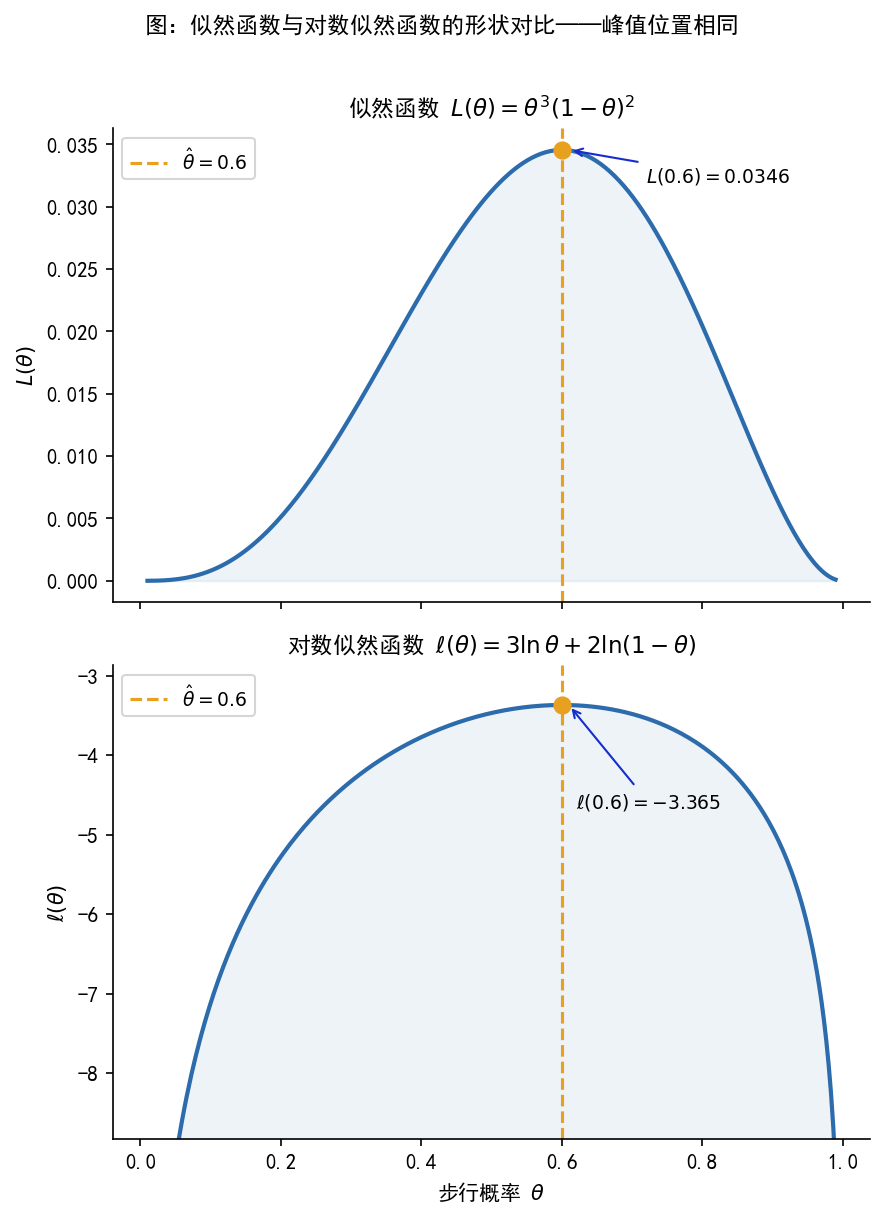

fig03 已保存


In [102]:
theta = np.linspace(0.01, 0.99, 300)
L     = theta**3 * (1 - theta)**2
lnL   = 3*np.log(theta) + 2*np.log(1 - theta)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

# 上图：L(θ)
ax1.plot(theta, L, color=COLOR_PRIMARY, lw=2)
ax1.fill_between(theta, L, alpha=0.08, color=COLOR_PRIMARY)
ax1.axvline(0.6, color=COLOR_SECONDARY, lw=1.5, ls='--', label='$\\hat{\\theta}=0.6$')
ax1.scatter([0.6], [0.6**3 * 0.4**2], color=COLOR_SECONDARY, zorder=5, s=60)
ax1.annotate(f'$L(0.6)={0.6**3*0.4**2:.4f}$',
             xy=(0.61, 0.6**3*0.4**2), xytext=(0.72, 0.032),
             fontsize=9, arrowprops=dict(arrowstyle='->', color=COLOR_NEUTRAL, lw=1))
ax1.set_ylabel('$L(\\theta)$', fontsize=10)
ax1.set_title('似然函数 $L(\\theta) = \\theta^3(1-\\theta)^2$', fontsize=11)
ax1.legend(fontsize=9)

# 下图：ℓ(θ)
ax2.plot(theta, lnL, color=COLOR_PRIMARY, lw=2)
ax2.fill_between(theta, lnL, np.min(lnL), alpha=0.08, color=COLOR_PRIMARY)
ax2.axvline(0.6, color=COLOR_SECONDARY, lw=1.5, ls='--', label='$\\hat{\\theta}=0.6$')
lnL_at_06 = 3*np.log(0.6) + 2*np.log(0.4)
ax2.scatter([0.6], [lnL_at_06], color=COLOR_SECONDARY, zorder=5, s=60)
ax2.annotate(f'$\\ell(0.6)={lnL_at_06:.3f}$',
             xy=(0.61, lnL_at_06), xytext=(0.62, lnL_at_06 - 1.3),
             fontsize=9, arrowprops=dict(arrowstyle='->', color=COLOR_NEUTRAL, lw=1))
ax2.set_xlabel('步行概率 $\\theta$', fontsize=10)
ax2.set_ylabel('$\\ell(\\theta)$', fontsize=10)
ax2.set_title('对数似然函数 $\\ell(\\theta) = 3\\ln\\theta + 2\\ln(1-\\theta)$', fontsize=11)
ax2.set_ylim(lnL.min() + 5, lnL.max() + 0.5)
ax2.legend(fontsize=9, loc='upper left')

fig.suptitle('图：似然函数与对数似然函数的形状对比——峰值位置相同', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('./figs/method_MLE_fig03_bernoulli_likelihood.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('fig03 已保存')

### fig04：网格搜索示意图

**图形说明**：展示网格搜索（Grid Search）的基本思路：在 $\theta$ 的参数空间上均匀取点，计算每个点的对数似然值，找出最大值点。这是数值优化算法最简单形式的可视化，为后续优化方法章节做铺垫。

**对应讲义**：第 3 节

**保存路径**：`./figs/method_MLE_fig04_bernoulli_grid.png`

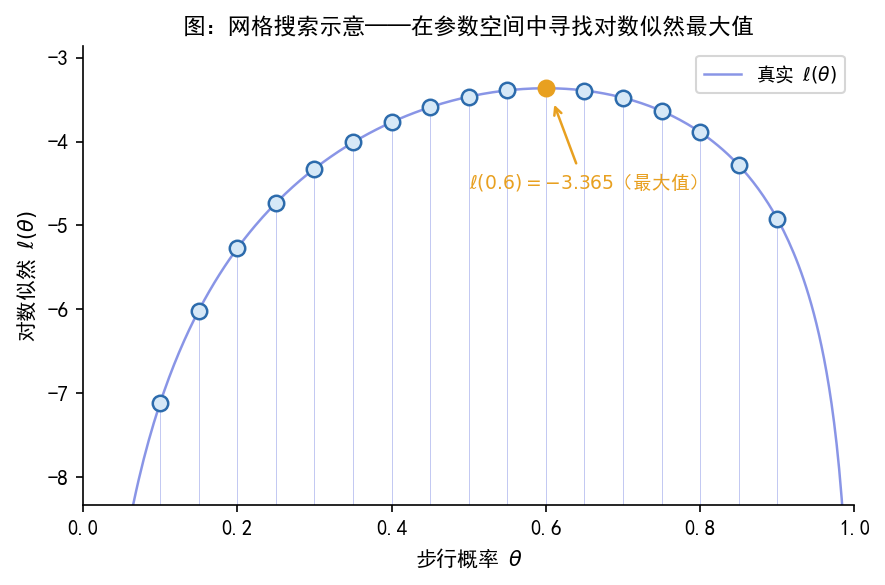

fig04 已保存


In [105]:
# 网格点
theta_grid = np.linspace(0.1, 0.9, 17)
lnL_grid   = 3*np.log(theta_grid) + 2*np.log(1 - theta_grid)
idx_max    = np.argmax(lnL_grid)

# 连续曲线（背景参考）
theta_cont = np.linspace(0.01, 0.99, 300)
lnL_cont   = 3*np.log(theta_cont) + 2*np.log(1 - theta_cont)

fig, ax = plt.subplots(figsize=(6,4))

# 背景曲线
ax.plot(theta_cont, lnL_cont, color=COLOR_NEUTRAL, lw=1.2, ls='-', alpha=0.5, label='真实 $\\ell(\\theta)$')

# 竖线（从网格点到 x 轴）
for i, (t, l) in enumerate(zip(theta_grid, lnL_grid)):
    color = COLOR_SECONDARY if i == idx_max else COLOR_FILL
    edge  = COLOR_SECONDARY if i == idx_max else COLOR_PRIMARY
    ax.vlines(t, lnL_cont.min() - 0.1, l, colors=COLOR_NEUTRAL, lw=0.4, alpha=0.3)
    ax.scatter(t, l, color=color, edgecolors=edge, zorder=5, s=55, linewidths=1.2)

# 标注最大值点
t_max = theta_grid[idx_max]
l_max = lnL_grid[idx_max]
ax.annotate(f'$\\ell (0.6)={l_max:.3f}$（最大值）',
            xy=(t_max+0.009, l_max-0.15), xytext=(t_max - 0.10, l_max - 1.2),
            fontsize=9, color=COLOR_SECONDARY,
            arrowprops=dict(arrowstyle='->', color=COLOR_SECONDARY, lw=1.2))

ax.set_xlabel('步行概率 $\\theta$', fontsize=10)
ax.set_ylabel('对数似然 $\\ell(\\theta)$', fontsize=10)
ax.set_title('图：网格搜索示意——在参数空间中寻找对数似然最大值', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(0.0, 1.0)
ax.set_ylim(lnL_cont.min() + 5.5, lnL_cont.max() + 0.5)

plt.tight_layout()
plt.savefig('./figs/method_MLE_fig04_bernoulli_grid.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('fig04 已保存')

---
## Section 4：参数化变换链示意图

**图形说明**：展示「线性预测器 → 连接函数 → 分布参数」的变换链，是正态线性模型、Logit 模型和 Poisson 模型共同骨架的可视化。三行分别对应三种模型，用不同颜色区分。

**对应讲义**：第 4 节

**保存路径**：`./figs/method_MLE_fig05_parameterization.png`

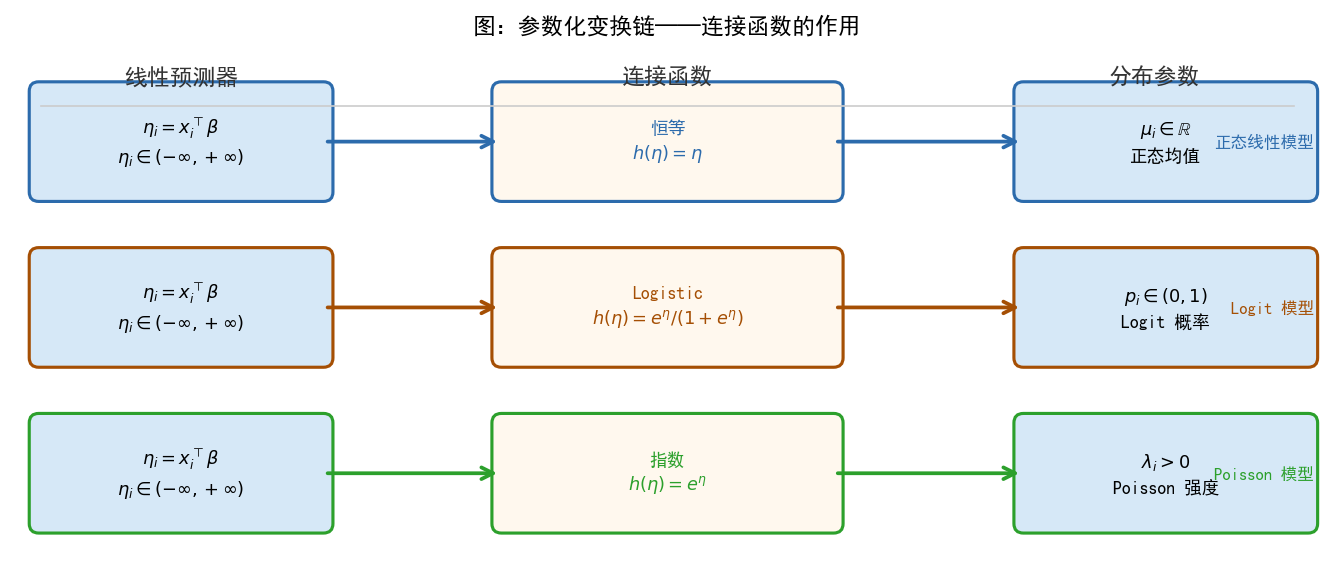

fig05 已保存


In [107]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.set_xlim(0, 11)
ax.set_ylim(0, 4.5)
ax.axis('off')

row_colors = [COLOR_PRIMARY, COLOR_ORANGE, COLOR_GREEN]
row_labels = ['正态线性模型', 'Logit 模型', 'Poisson 模型']
left_texts  = [
    '$\\eta_i = x_i^\\top\\beta$\n$\\eta_i \\in (-\\infty, +\\infty)$',
    '$\\eta_i = x_i^\\top\\beta$\n$\\eta_i \\in (-\\infty, +\\infty)$',
    '$\\eta_i = x_i^\\top\\beta$\n$\\eta_i \\in (-\\infty, +\\infty)$',
]
mid_texts  = ['恒等\n$h(\\eta) = \\eta$',
              'Logistic\n$h(\\eta) = e^\\eta/(1+e^\\eta)$',
              '指数\n$h(\\eta) = e^\\eta$']
right_texts = ['$\\mu_i \\in \\mathbb{R}$\n正态均值',
               '$p_i \\in (0,1)$\nLogit 概率',
               '$\\lambda_i > 0$\nPoisson 强度']

y_positions = [3.6, 2.2, 0.8]
box_w_lr, box_h = 2.4, 0.85
box_w_mid = 2.8

# 标题行
for x, title in zip([1.4, 5.5, 9.6], ['线性预测器', '连接函数', '分布参数']):
    ax.text(x, 4.15, title, ha='center', va='center', fontsize=11,
            fontweight='bold', color='#333333')
ax.axhline(3.9, color='#cccccc', lw=0.8, xmin=0.02, xmax=0.98)

for i, (y, color, mid, right) in enumerate(zip(y_positions, row_colors, mid_texts, right_texts)):
    # 左栏
    fancy_l = FancyBboxPatch((0.2, y - box_h/2), box_w_lr, box_h,
                              boxstyle='round,pad=0.08',
                              facecolor=COLOR_FILL, edgecolor=color, linewidth=1.5)
    ax.add_patch(fancy_l)
    ax.text(0.2 + box_w_lr/2, y, left_texts[i],
            ha='center', va='center', fontsize=8.5, linespacing=1.4)

    # 箭头 left→mid
    ax.annotate('', xy=(4.1, y), xytext=(2.6, y),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8, mutation_scale=14))

    # 中栏
    fancy_m = FancyBboxPatch((4.1, y - box_h/2), box_w_mid, box_h,
                              boxstyle='round,pad=0.08',
                              facecolor='#FFF8EE', edgecolor=color, linewidth=1.5)
    ax.add_patch(fancy_m)
    ax.text(4.1 + box_w_mid/2, y, mid,
            ha='center', va='center', fontsize=8.5, linespacing=1.4, color=color)

    # 箭头 mid→right
    ax.annotate('', xy=(8.5, y), xytext=(6.9, y),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8, mutation_scale=14))

    # 右栏
    fancy_r = FancyBboxPatch((8.5, y - box_h/2), box_w_lr, box_h,
                              boxstyle='round,pad=0.08',
                              facecolor=COLOR_FILL, edgecolor=color, linewidth=1.5)
    ax.add_patch(fancy_r)
    ax.text(8.5 + box_w_lr/2, y, right,
            ha='center', va='center', fontsize=8.5, linespacing=1.4)

    # 行标签（右侧）
    ax.text(10.95, y, row_labels[i], ha='right', va='center',
            fontsize=8, color=color, style='italic')

ax.set_title('图：参数化变换链——连接函数的作用', fontsize=11, y=0.98)
plt.tight_layout()
plt.savefig('./figs/method_MLE_fig05_parameterization.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('fig05 已保存')

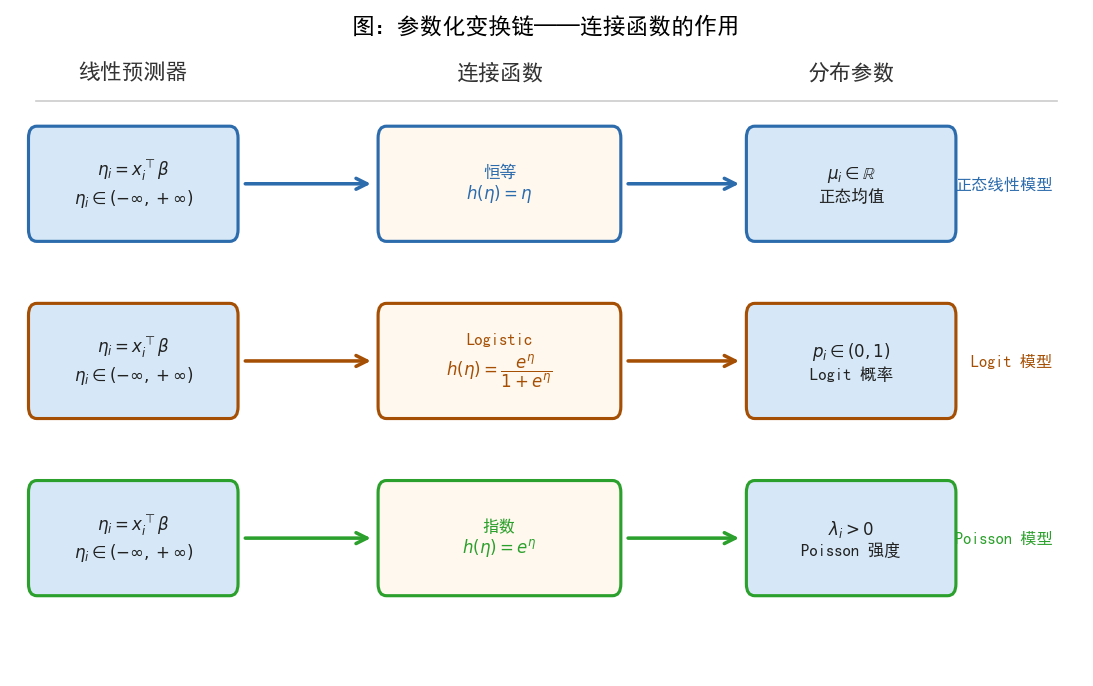

fig05 已保存


In [3]:
def add_box(ax, x, y, w, h, text, edgecolor, facecolor,
            fontsize=8.0, textcolor='#222222'):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle='round,pad=0.05,rounding_size=0.08',
        facecolor=facecolor,
        edgecolor=edgecolor,
        linewidth=1.5
    )
    ax.add_patch(patch)

    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha='center',
        va='center',
        fontsize=fontsize,
        color=textcolor,
        linespacing=1.22
    )


fig, ax = plt.subplots(figsize=(7.2, 4.5))
ax.set_xlim(0, 10.25)
ax.set_ylim(0, 4.30)
ax.axis('off')

row_colors = [COLOR_PRIMARY, COLOR_ORANGE, COLOR_GREEN]
row_labels = ['正态线性模型', 'Logit 模型', 'Poisson 模型']

left_texts = [
    '$\\eta_i = x_i^\\top \\beta$\n$\\eta_i \\in (-\\infty, +\\infty)$',
    '$\\eta_i = x_i^\\top \\beta$\n$\\eta_i \\in (-\\infty, +\\infty)$',
    '$\\eta_i = x_i^\\top \\beta$\n$\\eta_i \\in (-\\infty, +\\infty)$'
]

mid_texts = [
    '恒等\n$h(\\eta) = \\eta$',
    'Logistic\n$h(\\eta) = \\dfrac{e^{\\eta}}{1 + e^{\\eta}}$',
    '指数\n$h(\\eta) = e^{\\eta}$'
]

right_texts = [
    '$\\mu_i \\in \\mathbb{R}$\n正态均值',
    '$p_i \\in (0,1)$\nLogit 概率',
    '$\\lambda_i > 0$\nPoisson 强度'
]

y_positions = [3.30, 2.10, 0.90]

box_w_lr  = 1.92
box_w_mid = 2.24
box_h     = 0.68

left_x  = 0.18
mid_x   = 3.55
right_x = 7.10

arrow_gap = 0.12
label_x   = 10.00

header_y = 4.06
line_y   = 3.86

header_x = [
    left_x + box_w_lr / 2,
    mid_x + box_w_mid / 2,
    right_x + box_w_lr / 2
]

header_titles = ['线性预测器', '连接函数', '分布参数']

for x, title in zip(header_x, header_titles):
    ax.text(
        x, header_y, title,
        ha='center',
        va='center',
        fontsize=10.5,
        fontweight='bold',
        color='#333333'
    )

ax.axhline(
    line_y,
    color='#CCCCCC',
    lw=0.8,
    xmin=0.02,
    xmax=0.98
)

for i, y in enumerate(y_positions):

    color = row_colors[i]

    add_box(
        ax=ax,
        x=left_x,
        y=y - box_h / 2,
        w=box_w_lr,
        h=box_h,
        text=left_texts[i],
        edgecolor=color,
        facecolor=COLOR_FILL,
        fontsize=8.0,
        textcolor='#222222'
    )

    ax.annotate(
        '',
        xy=(mid_x - arrow_gap, y),
        xytext=(left_x + box_w_lr + arrow_gap, y),
        arrowprops=dict(
            arrowstyle='->',
            color=color,
            lw=1.7,
            mutation_scale=13,
            shrinkA=0,
            shrinkB=0
        )
    )

    add_box(
        ax=ax,
        x=mid_x,
        y=y - box_h / 2,
        w=box_w_mid,
        h=box_h,
        text=mid_texts[i],
        edgecolor=color,
        facecolor='#FFF8EE',
        fontsize=8.0,
        textcolor=color
    )

    ax.annotate(
        '',
        xy=(right_x - arrow_gap, y),
        xytext=(mid_x + box_w_mid + arrow_gap, y),
        arrowprops=dict(
            arrowstyle='->',
            color=color,
            lw=1.7,
            mutation_scale=13,
            shrinkA=0,
            shrinkB=0
        )
    )

    add_box(
        ax=ax,
        x=right_x,
        y=y - box_h / 2,
        w=box_w_lr,
        h=box_h,
        text=right_texts[i],
        edgecolor=color,
        facecolor=COLOR_FILL,
        fontsize=8.0,
        textcolor='#222222'
    )

    ax.text(
        label_x, y, row_labels[i],
        ha='right',
        va='center',
        fontsize=7.8,
        color=color,
        style='italic'
    )

ax.set_title(
    '图：参数化变换链——连接函数的作用',
    fontsize=11,
    y=0.985
)

plt.tight_layout(pad=0.40)

plt.savefig(
    './figs/method_MLE_fig05_parameterization.png',
    dpi=300,
    bbox_inches='tight',
    pad_inches=0.03,
    facecolor='white'
)

plt.savefig(
    './figs/method_MLE_fig05_parameterization.svg',
    bbox_inches='tight',
    pad_inches=0.03,
    facecolor='white'
)

plt.show()
print('fig05 已保存')

---
## Section 5：正态模型图形

### fig06：不同 $\mu$ 对数据的拟合效果

**图形说明**：生成 30 个来自 $N(170, 5^2)$ 的模拟身高数据，展示三条不同均值的正态密度曲线，直观说明「合适的参数让分布曲线更好地覆盖数据」。这是正态 MLE 的图形直觉。

**对应讲义**：第 5 节

**保存路径**：`./figs/method_MLE_fig06_normal_fit_mu.png`

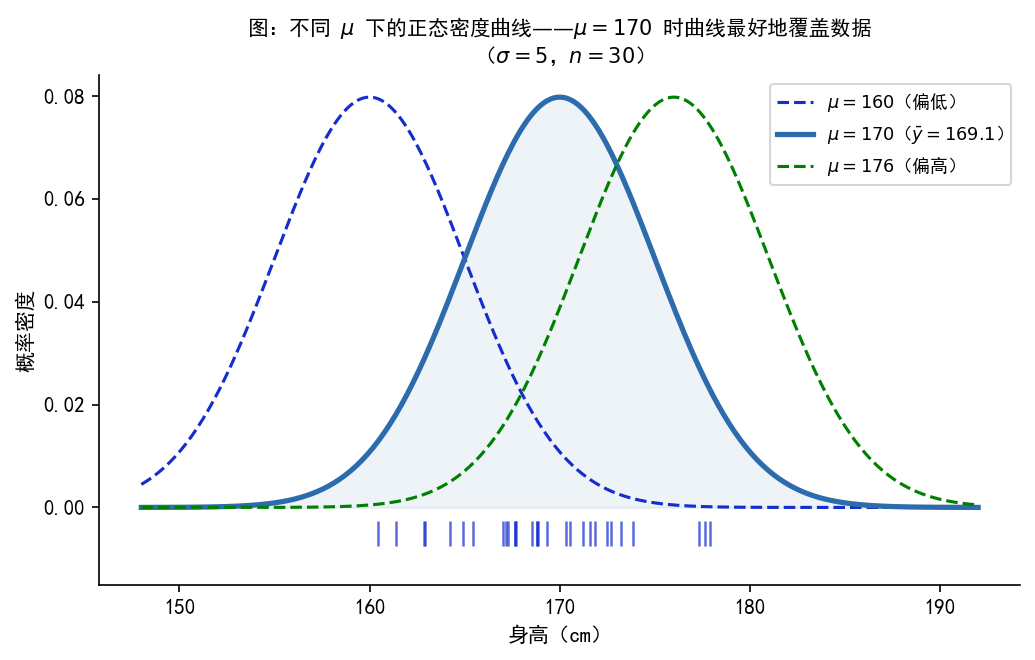

fig06 已保存  |  样本均值 ybar = 169.06


In [132]:
np.random.seed(42)
data_heights = np.random.normal(170, 5, 30)
ybar = data_heights.mean()

x_range = np.linspace(148, 192, 300)
sigma = 5

fig, ax = plt.subplots(figsize=(7, 4.5))

# Rug plot（底部数据点）
ax.plot(data_heights, np.full_like(data_heights, -0.005), '|',
        color=COLOR_NEUTRAL, markersize=12, markeredgewidth=1.2, alpha=0.7)

# 三条密度曲线
for mu, lw, ls, color, label in [
    (160, 1.5, '--', COLOR_NEUTRAL, '$\\mu=160$（偏低）'),
    (170, 2.5, '-',  COLOR_PRIMARY, f'$\\mu=170$（$\\bar{{y}}={ybar:.1f}$）'),
    (176, 1.5, '--', "GREEN", '$\\mu=176$（偏高）'),
]:
    pdf = stats.norm.pdf(x_range, mu, sigma)
    ax.plot(x_range, pdf, color=color, lw=lw, ls=ls, label=label)

ax.fill_between(x_range, stats.norm.pdf(x_range, 170, sigma), alpha=0.08, color=COLOR_PRIMARY)

ax.set_xlabel('身高（cm）', fontsize=10)
ax.set_ylabel('概率密度', fontsize=10)
ax.set_title(f'图：不同 $\\mu$ 下的正态密度曲线——$\\mu=170$ 时曲线最好地覆盖数据\n（$\\sigma=5$，$n=30$）',
             fontsize=10)
ax.legend(fontsize=8.5, loc='upper right')
ax.set_ylim(-0.015, None)

plt.tight_layout()
plt.savefig('./figs/method_MLE_fig06_normal_fit_mu.png',
            dpi=300, bbox_inches='tight')
plt.show()
print(f'fig06 已保存  |  样本均值 ybar = {ybar:.2f}')

### fig07：对数似然关于 $\mu$ 的曲线

**图形说明**：与 fig06 配合使用。展示对数似然 $\ell(\mu)$ 关于 $\mu$ 的变化曲线，峰值恰好在样本均值处，直观验证「正态模型的 MLE 估计量 = 样本均值」。

**对应讲义**：第 5 节

**保存路径**：`./figs/method_MLE_fig07_loglik_mu_curve.png`

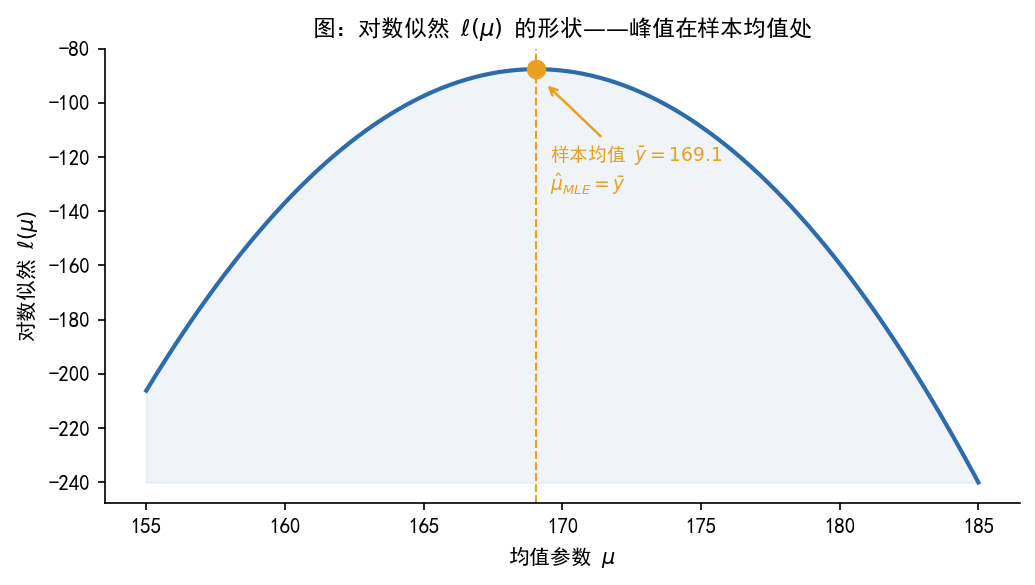

fig07 已保存


In [133]:
# 使用与 fig06 完全相同的数据（seed=42 已在上一 cell 执行）
mu_range = np.linspace(155, 185, 300)
n = len(data_heights)
sigma = 5  # 已知

lnL_mu = -n/2 * np.log(2*np.pi*sigma**2) - \
          1/(2*sigma**2) * np.array([np.sum((data_heights - mu)**2) for mu in mu_range])

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(mu_range, lnL_mu, color=COLOR_PRIMARY, lw=2)
ax.fill_between(mu_range, lnL_mu, lnL_mu.min(), alpha=0.07, color=COLOR_PRIMARY)

# 标注极值点
ax.axvline(ybar, color=COLOR_SECONDARY, lw=1.0, ls='--')
lnL_at_ybar = lnL_mu[np.argmin(np.abs(mu_range - ybar))]
ax.scatter([ybar], [lnL_at_ybar], color=COLOR_SECONDARY, zorder=5, s=70)
ax.annotate(f'样本均值 $\\bar{{y}}={ybar:.1f}$\n$\\hat{{\\mu}}_{{MLE}}=\\bar{{y}}$',
            xy=(ybar + 0.3, lnL_at_ybar - 5),
            xytext=(ybar + 0.5, lnL_at_ybar - 45),
            fontsize=9, color=COLOR_SECONDARY,
            arrowprops=dict(arrowstyle='->', color=COLOR_SECONDARY, lw=1.2))

ax.set_xlabel('均值参数 $\\mu$', fontsize=10)
ax.set_ylabel('对数似然 $\\ell(\\mu)$', fontsize=10)
ax.set_title('图：对数似然 $\\ell(\\mu)$ 的形状——峰值在样本均值处', fontsize=11)

plt.tight_layout()
plt.savefig('./figs/method_MLE_fig07_loglik_mu_curve.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('fig07 已保存')

---
## Section 6：OLS 与 MLE 等价性图

**图形说明**：生成简单线性回归数据，分别绘制残差平方和 RSS 和负对数似然 $-\ell$ 关于斜率参数 $\beta_1$ 的曲线，说明两者形状相同、极值位置相同——直观验证「OLS 是正态假设下 MLE 特例」。

**对应讲义**：第 5 节

**保存路径**：`./figs/method_MLE_fig08_ols_is_mle.png`

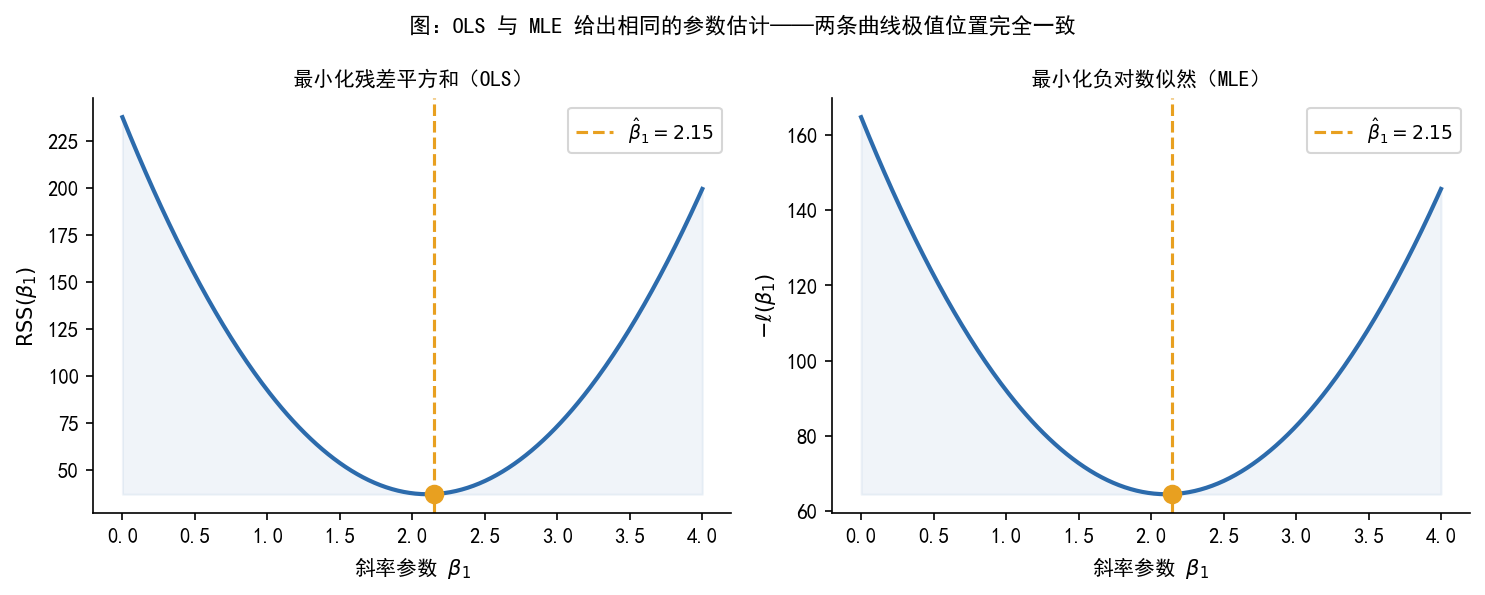

fig08 已保存  |  OLS 估计值 β1 = 2.1460（真实值 = 2.0）


In [121]:
np.random.seed(42)
n = 50
x  = np.random.normal(0, 1, n)
y  = 1 + 2*x + np.random.normal(0, 1, n)  # 真实 β0=1, β1=2

# OLS 估计截距（固定）
beta1_ols = np.cov(x, y)[0,1] / np.var(x)
beta0_ols = y.mean() - beta1_ols * x.mean()

beta1_range = np.linspace(0, 4, 300)
RSS   = np.array([np.sum((y - beta0_ols - b1*x)**2) for b1 in beta1_range])
sigma2 = 1.0  # 假设已知
neg_lnL = np.array([n/2*np.log(2*np.pi*sigma2) +
                     np.sum((y - beta0_ols - b1*x)**2)/(2*sigma2)
                     for b1 in beta1_range])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# 左图：RSS
ax1.plot(beta1_range, RSS, color=COLOR_PRIMARY, lw=2)
ax1.fill_between(beta1_range, RSS, RSS.min(), alpha=0.07, color=COLOR_PRIMARY)
ax1.axvline(beta1_ols, color=COLOR_SECONDARY, lw=1.5, ls='--',
            label=f'$\\hat{{\\beta}}_1 = {beta1_ols:.2f}$')
ax1.scatter([beta1_ols], [RSS[np.argmin(np.abs(beta1_range - beta1_ols))]],
            color=COLOR_SECONDARY, zorder=5, s=70)
ax1.set_xlabel('斜率参数 $\\beta_1$', fontsize=10)
ax1.set_ylabel('$\\text{RSS}(\\beta_1)$', fontsize=10)
ax1.set_title('最小化残差平方和（OLS）', fontsize=10)
ax1.legend(fontsize=9)

# 右图：负对数似然
ax2.plot(beta1_range, neg_lnL, color=COLOR_PRIMARY, lw=2)
ax2.fill_between(beta1_range, neg_lnL, neg_lnL.min(), alpha=0.07, color=COLOR_PRIMARY)
ax2.axvline(beta1_ols, color=COLOR_SECONDARY, lw=1.5, ls='--',
            label=f'$\\hat{{\\beta}}_1 = {beta1_ols:.2f}$')
ax2.scatter([beta1_ols], [neg_lnL[np.argmin(np.abs(beta1_range - beta1_ols))]],
            color=COLOR_SECONDARY, zorder=5, s=70)
ax2.set_xlabel('斜率参数 $\\beta_1$', fontsize=10)
ax2.set_ylabel('$-\\ell(\\beta_1)$', fontsize=10)
ax2.set_title('最小化负对数似然（MLE）', fontsize=10)
ax2.legend(fontsize=9)

fig.suptitle('图：OLS 与 MLE 给出相同的参数估计——两条曲线极值位置完全一致', fontsize=10.5)
plt.tight_layout()
plt.savefig('./figs/method_MLE_fig08_ols_is_mle.png',
            dpi=300, bbox_inches='tight')
plt.show()
print(f'fig08 已保存  |  OLS 估计值 β1 = {beta1_ols:.4f}（真实值 = 2.0）')

---
## Section 7：生成模拟数据

以下三个数据集供 `MLE_case.ipynb` 使用，同时也可供后续 Logit/Probit、Poisson 等章节直接引用。

### 数据 01：`method_MLE_data01_normal_linear.csv`

**数据说明**：正态线性模型的模拟数据，用于演示 OLS 与 MLE 的等价性。

**DGP**：$y_i = 1 + 2x_{1i} - 0.5x_{2i} + \varepsilon_i$，$\varepsilon_i \sim N(0, 1.5^2)$，$n=500$

**后续用途**：`MLE_case.ipynb` Case 1，以及后续章节有需要时复用。

In [134]:
np.random.seed(2024)
n   = 500
x1  = np.random.normal(0, 1, n)
x2  = np.random.normal(0, 1, n)
eps = np.random.normal(0, 1.5, n)
y   = 1 + 2*x1 - 0.5*x2 + eps

df1 = pd.DataFrame({'y': y, 'x1': x1, 'x2': x2})
df1.to_csv('./data/method_MLE_data01_normal_linear.csv', index=False)
print(f'数据 01 已保存，形状：{df1.shape}')
print(df1.describe().round(3))

数据 01 已保存，形状：(500, 3)
             y       x1       x2
count  500.000  500.000  500.000
mean     0.836   -0.026    0.074
std      2.741    1.058    0.969
min     -6.949   -3.421   -3.673
25%     -0.895   -0.714   -0.572
50%      0.709   -0.046    0.063
75%      2.728    0.664    0.762
max      8.153    3.576    2.556


### 数据 02：`method_MLE_data02_logit.csv`

**数据说明**：Logit 模型的模拟数据，模拟「信用卡违约」场景。

**DGP**：潜变量 $y_i^* = -2 + 1.5 \cdot \text{income}_i - 0.8 \cdot \text{age\_std}_i + u_i$，$u_i \sim \text{Logistic}(0,1)$，$y_i = \mathbf{1}[y_i^* > 0]$

其中 $\text{income}_i \sim N(5,1)$（万元/月），$\text{age\_std}_i$ 为年龄的标准化值。

**后续用途**：`MLE_case.ipynb` Case 2，以及后续 Logit/Probit 章节。

In [135]:
np.random.seed(2024)
n       = 1000
income  = np.random.normal(5, 1, n)
age_std = (np.random.normal(35, 8, n) - 35) / 8
u       = np.random.logistic(0, 1, n)
y_star  = -2 + 1.5*income - 0.8*age_std + u
y       = (y_star > 0).astype(int)

df2 = pd.DataFrame({'default': y, 'income': income, 'age_std': age_std})
df2.to_csv('./data/method_MLE_data02_logit.csv', index=False)
print(f'数据 02 已保存，形状：{df2.shape}')
print(f'违约率：{y.mean():.3f}（{y.sum()} 人违约）')
print(df2.describe().round(3))

数据 02 已保存，形状：(1000, 3)
违约率：0.986（986 人违约）
        default    income   age_std
count  1000.000  1000.000  1000.000
mean      0.986     5.024    -0.032
std       0.118     1.015     1.025
min       0.000     1.327    -2.904
25%       1.000     4.342    -0.740
50%       1.000     5.012    -0.014
75%       1.000     5.727     0.682
max       1.000     8.576     4.402


### 数据 03：`method_MLE_data03_poisson.csv`

**数据说明**：Poisson 模型的模拟数据，模拟「月度交易次数」场景。

**DGP**：$y_i \sim \text{Poisson}(\lambda_i)$，$\ln\lambda_i = 0.5 + 0.3 \cdot \text{income}_i + 0.2 \cdot \text{experience}_i$，其中 income 和 experience 均来自标准正态分布。

**后续用途**：`MLE_case.ipynb` Case 3，以及后续 Poisson/计数数据模型章节。

In [136]:
np.random.seed(2024)
n          = 800
income     = np.random.normal(0, 1, n)
experience = np.random.normal(0, 1, n)
lam        = np.exp(0.5 + 0.3*income + 0.2*experience)
y          = np.random.poisson(lam)

df3 = pd.DataFrame({'trade_count': y, 'income': income, 'experience': experience})
df3.to_csv('./data/method_MLE_data03_poisson.csv', index=False)
print(f'数据 03 已保存，形状：{df3.shape}')
print(f'交易次数均值：{y.mean():.3f}，最大值：{y.max()}')
print(df3.describe().round(3))

数据 03 已保存，形状：(800, 3)
交易次数均值：1.734，最大值：9
       trade_count   income  experience
count      800.000  800.000     800.000
mean         1.734   -0.000      -0.013
std          1.445    1.036       0.999
min          0.000   -3.673      -2.904
25%          1.000   -0.686      -0.714
50%          1.000   -0.012       0.005
75%          3.000    0.692       0.611
max          9.000    3.576       4.402


---
## 汇总确认

运行以下 Cell，验证所有图形和数据文件均已正确生成。

In [137]:
import os

expected_figs = [
    'method_MLE_fig01_flowchart.png',
    'method_MLE_fig02_prob_vs_likelihood.png',
    'method_MLE_fig03_bernoulli_likelihood.png',
    'method_MLE_fig04_bernoulli_grid.png',
    'method_MLE_fig05_parameterization.png',
    'method_MLE_fig06_normal_fit_mu.png',
    'method_MLE_fig07_loglik_mu_curve.png',
    'method_MLE_fig08_ols_is_mle.png',
]
expected_data = [
    'method_MLE_data01_normal_linear.csv',
    'method_MLE_data02_logit.csv',
    'method_MLE_data03_poisson.csv',
]

print('── 图形文件检查 ────────────────────────')
for f in expected_figs:
    path = f'./figs/{f}'
    status = '✓' if os.path.exists(path) else '✗ 缺失！'
    size = f'  ({os.path.getsize(path)/1024:.1f} KB)' if os.path.exists(path) else ''
    print(f'  {status}  {f}{size}')

print()
print('── 数据文件检查 ────────────────────────')
for f in expected_data:
    path = f'./data/{f}'
    status = '✓' if os.path.exists(path) else '✗ 缺失！'
    if os.path.exists(path):
        df = pd.read_csv(path)
        size_info = f'  ({df.shape[0]} 行 × {df.shape[1]} 列)'
    else:
        size_info = ''
    print(f'  {status}  {f}{size_info}')

── 图形文件检查 ────────────────────────
  ✓  method_MLE_fig01_flowchart.png  (70.5 KB)
  ✓  method_MLE_fig02_prob_vs_likelihood.png  (182.3 KB)
  ✓  method_MLE_fig03_bernoulli_likelihood.png  (221.4 KB)
  ✓  method_MLE_fig04_bernoulli_grid.png  (125.6 KB)
  ✓  method_MLE_fig05_parameterization.png  (151.2 KB)
  ✓  method_MLE_fig06_normal_fit_mu.png  (182.3 KB)
  ✓  method_MLE_fig07_loglik_mu_curve.png  (133.9 KB)
  ✓  method_MLE_fig08_ols_is_mle.png  (182.2 KB)

── 数据文件检查 ────────────────────────
  ✓  method_MLE_data01_normal_linear.csv  (500 行 × 3 列)
  ✓  method_MLE_data02_logit.csv  (1000 行 × 3 列)
  ✓  method_MLE_data03_poisson.csv  (800 行 × 3 列)
